# 1. Introducción

### Pregunta de investigación

¿Cómo se relaciona el uso del celulares con los patrones de sueño?




###Contexto

Actualmente, los teléfonos son una herramienta indispensable para la comunicación con amigos o familiares, para entretenimiento, trabajo o estudio. En general las personas usan una cantidad considerable de su tiempo usando el celular. Dependiendo de a qué tipo de información estén expuestos, el uso constante puede tener efectos negativos en la salud física y mental.

Uno de los aspectos más importantes es el impacto del uso del celular en los patrones del sueño, dado que el uso prolongado de pantallas, especialmente antes de dormir, puede alterar el reloj biológico interno debido a la exposición a la luz azul, al igual que retrasa la hora de dormir, y reduce la calidad y duración del sueño.

###Relación entre el problema y la base de datos seleccionada

Para analizar esta problemática, se escogió la base de datos [Screen Time, Sleep & Stress Analysis Dataset](https://www.kaggle.com/datasets/amar5693/screen-time-sleep-and-stress-analysis-dataset?resource=download) disponble en Kaggle. Este dataset contiene información sobre el comportamiento de uso del teléfono celular y su relación con los patrones de sueño, los niveles de estrés y la productividad. Incluye variables cuantitativas y categóricas que permiten examinar cómo el uso diario del celular se asocia con las horas y la calidad del sueño, facilitando el análisis del impacto de los hábitos digitales en el descanso de las personas.

# 2. Descripción de la base de datos



*   El dataset cuenta con 50,000 registros y 13 características
*   Las variables más importantes para nuestra problemática son:
    *   **Sleep_Hours:** la cantidad de horas que durmió un usuario al día.
    *   **Daily_Phone_Hours:** cantidad de horas que un usuario utilizó su teléfono celular.
    *   **Age:** edad del usuario
    *   **Weekend_Screen_Time_Hours:** cantidad de horas que el usuario utilizó su teléfono celular los fines de semana.
    * **App_Usage_Count:** cantidad de veces que un usuario abre una aplicación móvil.






### Visualización de datos

In [ ]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


### Número de registro y variables

In [ ]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 50000
Número de variables: 13


### Tipos de datos

Contamos con 9 variables cuantitativas y 4 variables categóricas

In [ ]:
df.dtypes.value_counts()

,count
int64,5
object,4
float64,4


In [ ]:
cuantitativas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables cuantitativas:")
print("\n".join([f"- {col}" for col in cuantitativas]))

print("\nVariables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

Variables cuantitativas:
- Age
- Daily_Phone_Hours
- Social_Media_Hours
- Work_Productivity_Score
- Sleep_Hours
- Stress_Level
- App_Usage_Count
- Caffeine_Intake_Cups
- Weekend_Screen_Time_Hours

Variables categóricas:
- User_ID
- Gender
- Occupation
- Device_Type


### Descripción de variables numéricas

In [ ]:
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


# 3. Análisis inicial de las variables

Observamos que el dataset no cuenta con valores nulos en alguna de sus varuables, lo que permite realizar un análisis sin necesidad de pasos adicionales como eliminación de registros.

In [ ]:
nulos = (df.isnull().mean()*100).reset_index()
nulos.columns = ['variable', 'porcentaje_nulos']
nulos

,variable,porcentaje_nulos
0,User_ID,0.0
1,Age,0.0
2,Gender,0.0
3,Occupation,0.0
4,Device_Type,0.0
5,Daily_Phone_Hours,0.0
6,Social_Media_Hours,0.0
7,Work_Productivity_Score,0.0
8,Sleep_Hours,0.0
9,Stress_Level,0.0


### Análisis de variables categóricas

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,16708
Female,16679
Other,16613


In [ ]:
df['Device_Type'].value_counts()

,count
Device_Type,
Android,25080
iOS,24920


In [ ]:
df['Occupation'].value_counts()

,count
Occupation,
Professional,12629
Student,12517
Business Owner,12459
Freelancer,12395


### Descripción de variables cuantitativas

In [ ]:
variables_cuantitativas = ['Daily_Phone_Hours', 'Social_Media_Hours',	'Work_Productivity_Score',	'Sleep_Hours',	'Stress_Level','App_Usage_Count', 'Caffeine_Intake_Cups',	'Weekend_Screen_Time_Hours']
df[variables_cuantitativas].head()

,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,1.3,6.7,6,8.8,4,42,1,8.7
1,1.2,1.5,5,6.4,1,51,3,5.1
2,5.3,5.7,5,9.0,4,14,5,6.3
3,5.8,2.5,2,5.7,3,36,6,12.8
4,7.9,1.3,4,5.7,3,37,5,9.9


### Variables por categoría

Se calculan mínimo, máximo y media de las variables:

*   Sleep_Hours
*   Daily_Phone_Hours
*   Weekend_Screen_Time_Hours

Para ver el comportamiento general del dataset

In [ ]:
df['Sleep_Hours'].min(), df['Sleep_Hours'].max(), df['Sleep_Hours'].mean()
df['Daily_Phone_Hours'].min(), df['Daily_Phone_Hours'].max(), df['Daily_Phone_Hours'].mean()
df['Weekend_Screen_Time_Hours'].min(), df['Weekend_Screen_Time_Hours'].max(), df['Weekend_Screen_Time_Hours'].mean()

cols = ['Sleep_Hours', 'Daily_Phone_Hours', 'Weekend_Screen_Time_Hours']

df[cols].agg(['min', 'max', 'mean'])
df[cols].describe()

,Sleep_Hours,Daily_Phone_Hours,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000
mean,6.497744,6.509116,8.006844
std,1.449551,3.170903,3.461300
min,4.000000,1.000000,2.000000
25%,5.200000,3.800000,5.000000
50%,6.500000,6.500000,8.000000
75%,7.800000,9.200000,11.000000
max,9.000000,12.000000,14.000000


# 4. Visualizaciones exploratorias básicas

### Histograma: horas de sueño

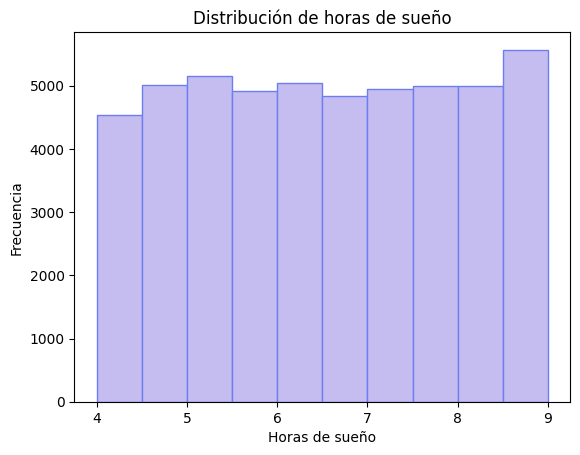

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Sleep_Hours'], color='#C5BCF0', edgecolor='#6C7EF0')
plt.xlabel("Horas de sueño")
plt.ylabel("Frecuencia")
plt.title("Distribución de horas de sueño")
plt.show()

### Gráfico de dispersión para las variables tiempo en pantalla y horas de sueño

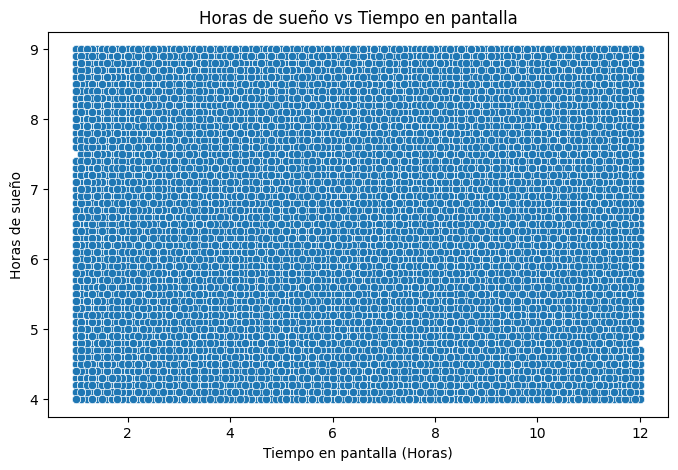

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Daily_Phone_Hours', y='Sleep_Hours')
plt.title("Horas de sueño vs Tiempo en pantalla")
plt.xlabel("Tiempo en pantalla (Horas)")
plt.ylabel("Horas de sueño")
plt.show()

Como podemos observar, se presenta un caso de overplotting, por lo que se procede a realizar otro tipo de gráfica

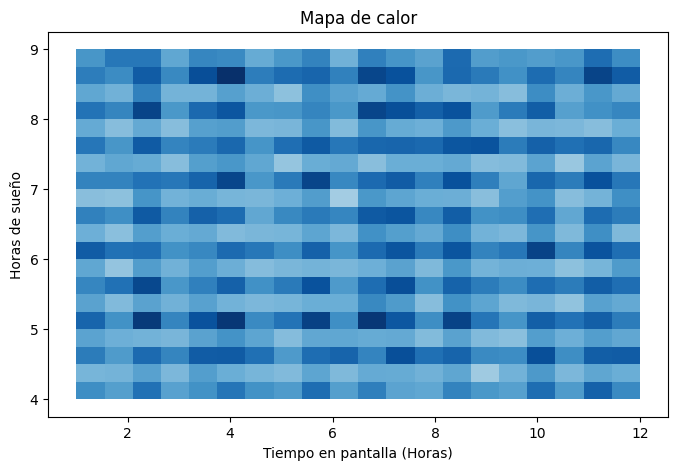

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,
             x='Daily_Phone_Hours',
             y='Sleep_Hours',
             bins=20,
             cmap='Blues')

plt.title("Mapa de calor")
plt.xlabel("Tiempo en pantalla (Horas)")
plt.ylabel("Horas de sueño")
plt.show()

En esta gráfica se observa que la densidad se ve bastante homogénea, por lo que se procede a verificar la correlación

In [ ]:
df[['Daily_Phone_Hours','Sleep_Hours']].corr()

,Daily_Phone_Hours,Sleep_Hours
Daily_Phone_Hours,1.000000,-0.003434
Sleep_Hours,-0.003434,1.000000


La correlación es prácticamente 0, lo cual evidencia que no existe relación lineal y las variables son completamente independientes.

### Visualización para relación entre uso del celular y el puntaje de productividad en el trabajo

Para analizar la relación entre el uso del celular y la productividad en el trabajo, se optó por un gráfico de dispersión, el cual nos permite identificar la posible relación entre estas dos variables.

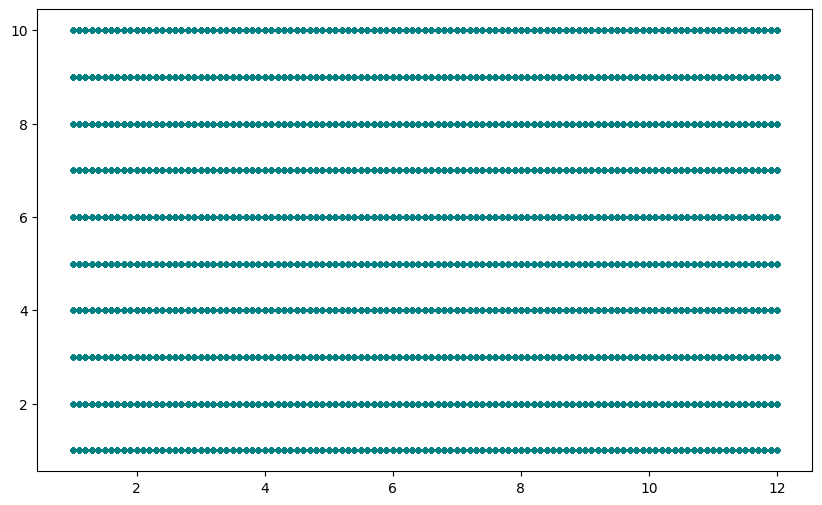

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    df['Daily_Phone_Hours'],
    df['Work_Productivity_Score'],
    s=10,
    alpha=0.4,
    c='teal'
)
plt.show()

# 5. Interpretaciones iniciales

*   Hay balance en la variable de género para las 3 categorías de las cuales se dispone (masculino, femenino, otro), por lo que no debería presentar sesgo.
*   La escala de estrés se representa mediante una escala continua de 1 a 10. Esta puede ser subjetiva, por lo que puede afectar la precisión
*   No se observa ningún dato atípico
*   Mediante gráficas y coeficiente de correlación, identificamos ausencia de relación lineal entre diversas variables vs. las horas de sueño y refuerza la hipótesis de que los datos fueron generados de forma sintética y sin similitud a datos reales (esta hipótesis se profundizará en la sección de conclusiones).



# 6. Conclusiones

A partir del análisis exploratorio con este dataset, no se puede evidenciar una relación clara que pruebe que las horas del uso del celular impacten el sueño. Esto se debe a que la base de datos utilizada, fue construida de forma balanceada, distribuyendo las variables de forma uniforme entre sus rangos.

Por esto, las variables de uso de celular y horas de sueño no representan una correlación significativa, lo que limita la identificación de patrones reales de dependencia entre ambas.

Para evaluar posibles limitaciones del conjunto de datos, se analizó el impacto del uso del celular sobre otras variables como la productividad laboral y los niveles de estrés. Sin embargo, los resultados tampoco evidenciaron una relación significativa entre el uso del celular y dichas variables, lo que refuerza la hipótesis de que el dataset presenta una estructura sintética o balanceada que limita la identificación de patrones reales.

# 7. Referencias

Fuente de los datos
* **Dataset:** Screen Time, Sleep & Stress Analysis Dataset
* **Repositorio:** Kaggle
* **Autores:** Amar Tiwari
* **Descripción:** datos que analizan el uso del celular y su relación con la productividad, patrones del sueño, y niveles de estrés.